# Gomi - Full Training Pipeline

**Step 1:** Fine-tune DistilBERT
**Step 2:** Train Logistic Regression risk fusion model
**Step 3:** Push both models to Hugging Face

> Make sure **Runtime → Change runtime type → T4 GPU** is selected before running.

---
**Hugging Face repos:**
- Dataset: `GitRatBCSAD/gomi-datasets`
- Sentiment model: `GitRatBCSAD/gomi-sentiment`
- Risk model: `GitRatBCSAD/gomi-risk`

In [ ]:
import torch
import torchvision.io

class _VideoReaderStub:
    pass

torchvision.io.VideoReader = _VideoReaderStub

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('WARNING: No GPU detected. Go to Runtime → Change runtime type → T4 GPU')

CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install -q transformers==4.44.2 datasets scikit-learn imbalanced-learn huggingface_hub joblib shap lizard nlpaug nltk

In [ ]:
from google.colab import userdata
from huggingface_hub import login
import os

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN, add_to_git_credential=False)
print('Logged in to Hugging Face.')

Logged in to Hugging Face.


In [ ]:
HF_DATASET_REPO = 'GitRatBCSAD/gomi-datasets'
HF_SENTIMENT_REPO = 'GitRatBCSAD/gomi-sentiment'
HF_RISK_REPO = 'GitRatBCSAD/gomi-risk'

BASE_MODEL = 'distilbert-base-uncased'

# 3-class: frustration+caution merged into 'caution' since both are risk-positive
LABELS = ['caution', 'neutral', 'satisfaction']
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}
VALID_EMOTIONS = set(LABELS)  # for trained-model output validation
RAW_EMOTIONS = {'frustration', 'caution', 'neutral', 'satisfaction'}  # dataset raw labels
EMOTION_TO_LABEL = {  # map openreview 4-label dataset → 3-class training target
    'frustration': 'caution',
    'caution': 'caution',
    'neutral': 'neutral',
    'satisfaction':'satisfaction',
}

# Training hyperparameters
MAX_LENGTH = 128
BATCH_SIZE = 32 # good enough for T4 with DistilBERT
NUM_EPOCHS = 5
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
TEST_SIZE = 0.15
RANDOM_SEED = 42

os.makedirs('models/distilbert_sentiment', exist_ok=True)
os.makedirs('models/risk', exist_ok=True)

print('Config done.')

Config done.


In [ ]:
from huggingface_hub import HfApi

hf_api = HfApi()

## Step 1 - Fine-tune DistilBERT

NOTE: Skip this if DistilBERT is already trained.

In [ ]:
# raise SystemExit("SKIP - DistilBERT already on HF.")

### DistilBERT Training Baselines

Target: macro F1 ≥ 0.70 on 3-class imbalanced commit-message data.

| Reference | Result |
|-----------|--------|
| Biswas et al. 2021 (arXiv:2106.02581) | BERT/DistilBERT +6–12% F1 over SentiCR |
| Lin et al. 2024 (arXiv:2310.11113) | macro F1 0.65–0.94 on balanced SE datasets |
| Obaido et al. 2024 (PMC11132486) | fuzzy BERT ensemble max macro F1 0.883 |

Training uses class-weighted cross-entropy only. Instance-level intensity weighting removed.


In [ ]:
import csv
import random
from collections import Counter
from huggingface_hub import hf_hub_download

def load_labeled_csv(filename, so_mapping=False):
    path = hf_hub_download(HF_DATASET_REPO, f'openreview/{filename}', repo_type='dataset', token=HF_TOKEN)
    messages, label_ids = [], []
    skipped = 0

    with open(path, newline='', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            if so_mapping:
                msg = row.get('text', '').strip()
                oracle = row.get('oracle', '').strip()

                if oracle == '1':    emotion = 'satisfaction'
                elif oracle == '0':  emotion = 'neutral'
                elif oracle == '-1': emotion = 'caution'
                else: continue
            else:
                msg = row.get('message', '').strip()
                raw = row.get('reconciled_emotion', '').strip().lower()
                if raw not in RAW_EMOTIONS:
                    skipped += 1; continue
                emotion = EMOTION_TO_LABEL[raw]

            if not msg or emotion not in VALID_EMOTIONS:
                skipped += 1; continue

            messages.append(msg)
            label_ids.append(LABEL2ID[emotion])

    print(f'  {filename}: Loaded {len(messages)} rows (skipped {skipped})')
    return messages, label_ids

print('[1/4] Loading datasets...')
msgs_2k,  ids_2k  = load_labeled_csv('openreview_labeled_2k.csv')
msgs_scr, ids_scr = load_labeled_csv('senticr_labeled.csv')
msgs_so,  ids_so  = load_labeled_csv('StackOverflow.csv', so_mapping=True)
msgs_gh,  ids_gh  = load_labeled_csv('github.csv', so_mapping=True)

messages = msgs_2k + msgs_scr + msgs_so + msgs_gh
label_ids = ids_2k + ids_scr + ids_so + ids_gh

# Balance: cap any class at MIN_CLASS * MAX_RATIO.
MAX_RATIO = 1.3
random.seed(RANDOM_SEED)
counts = Counter(label_ids)
min_count = min(counts.values())
cap_target = int(min_count * MAX_RATIO)

for cls_id, cnt in counts.items():
    if cnt > cap_target:
        cls_idx = [i for i, l in enumerate(label_ids) if l == cls_id]
        drop = set(cls_idx) - set(random.sample(cls_idx, cap_target))
        messages = [m for i, m in enumerate(messages)  if i not in drop]
        label_ids = [l for i, l in enumerate(label_ids) if i not in drop]

print(f'\nPre-split pool: {len(messages)} samples.')
dist = Counter(LABELS[i] for i in label_ids)
for lbl, cnt in sorted(dist.items()):
    print(f'    {lbl:<14} {cnt:>5}  ({100*cnt/len(label_ids):.1f}%)')


[1/4] Loading datasets...


openreview_labeled_2k.csv: 0.00B [00:00, ?B/s]

  openreview_labeled_2k.csv: Loaded 2000 rows (skipped 0)


senticr_labeled.csv: 0.00B [00:00, ?B/s]

  senticr_labeled.csv: Loaded 1600 rows (skipped 0)


StackOverflow.csv: 0.00B [00:00, ?B/s]

  StackOverflow.csv: Loaded 1500 rows (skipped 0)


github.csv: 0.00B [00:00, ?B/s]

  github.csv: Loaded 7122 rows (skipped 0)

Pre-split pool: 9600 samples.
    caution         3434  (35.8%)
    neutral         3485  (36.3%)
    satisfaction    2681  (27.9%)


In [ ]:
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from datasets import Dataset

train_msgs, val_msgs, train_labels, val_labels = train_test_split(
    messages, label_ids,
    test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=label_ids
)
print(f'Split: {len(train_msgs)} train | {len(val_msgs)} val')

dist = Counter(LABELS[i] for i in train_labels)
for lbl, cnt in sorted(dist.items()):
    print(f'  {lbl:<14} {cnt:>5}  ({100*cnt/len(train_labels):.1f}%)')

print(f'\nLoading tokenizer ({BASE_MODEL})...')
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

train_ds = (
    Dataset.from_dict({'text': train_msgs, 'label': train_labels})
    .map(tokenize, batched=True).remove_columns(['text'])
)
val_ds = (
    Dataset.from_dict({'text': val_msgs, 'label': val_labels})
    .map(tokenize, batched=True).remove_columns(['text'])
)
train_ds.set_format('torch')
val_ds.set_format('torch')
collator = DataCollatorWithPadding(tokenizer=tokenizer)
print('Tokenization done.')


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Split: 8160 train | 1440 val
  caution         2919  (35.8%)
  neutral         2962  (36.3%)
  satisfaction    2279  (27.9%)

Loading tokenizer (distilbert-base-uncased)...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/8160 [00:00<?, ? examples/s]

Map:   0%|          | 0/1440 [00:00<?, ? examples/s]

Tokenization done.


In [ ]:
import numpy as np
import torch.nn as nn
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

print(f'[3/4] Loading {BASE_MODEL} and attaching classification head...')
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL, num_labels=len(LABELS), id2label=ID2LABEL, label2id=LABEL2ID
)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(model.device)
print(f'Class weights (label balance): {class_weights}')

class ClassWeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor.to(logits.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    report = classification_report(labels, preds, target_names=LABELS, output_dict=True, zero_division=0)
    return {'accuracy': report['accuracy'], 'f1_macro': report['macro avg']['f1-score'],
            'precision': report['macro avg']['precision'], 'recall': report['macro avg']['recall']}

args = TrainingArguments(
    output_dir='models/distilbert_sentiment/checkpoints',
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=20,
    report_to='none',
    seed=RANDOM_SEED,
    fp16=torch.cuda.is_available(),
)

trainer = ClassWeightedTrainer(
    model=model, args=args,
    train_dataset=train_ds, eval_dataset=val_ds,
    tokenizer=tokenizer, data_collator=collator,
    compute_metrics=compute_metrics,
)

print(f'[4/4] Fine-tuning for {NUM_EPOCHS} epochs on {len(train_msgs)} samples...')
trainer.train()


[3/4] Loading distilbert-base-uncased and attaching classification head...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Class weights (label balance): [0.93182597 0.91829845 1.19350592]
[4/4] Fine-tuning for 5 epochs on 8160 samples...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.491400,0.459953,0.813194,0.812776,0.813460,0.812355
2,0.391500,0.426757,0.831944,0.833155,0.833914,0.832470
3,0.308200,0.429882,0.844444,0.845181,0.844855,0.845527
4,0.234100,0.470000,0.840972,0.841982,0.842057,0.841966
5,0.214500,0.504514,0.838889,0.840160,0.842085,0.839588


TrainOutput(global_step=1275, training_loss=0.3458229274375766, metrics={'train_runtime': 195.7935, 'train_samples_per_second': 208.383, 'train_steps_per_second': 6.512, 'total_flos': 1238815808296128.0, 'train_loss': 0.3458229274375766, 'epoch': 5.0})

Final evaluation on validation set:


              precision    recall  f1-score   support

     caution       0.85      0.85      0.85       515
     neutral       0.83      0.83      0.83       523
satisfaction       0.85      0.86      0.85       402

    accuracy                           0.84      1440
   macro avg       0.84      0.85      0.85      1440
weighted avg       0.84      0.84      0.84      1440



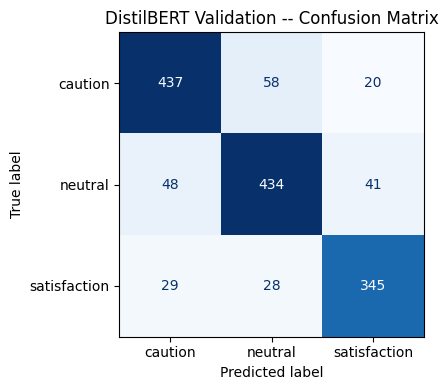

Confusion matrix saved.
Model saved to: models/distilbert_sentiment


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print('Final evaluation on validation set:')
preds_out = trainer.predict(val_ds)
preds = np.argmax(preds_out.predictions, axis=-1)

print(classification_report(val_labels, preds, target_names=LABELS, zero_division=0))

cm = confusion_matrix(val_labels, preds, labels=list(range(len(LABELS))))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('DistilBERT Validation -- Confusion Matrix')
plt.tight_layout()
plt.savefig('models/distilbert_sentiment/confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved.')

SENTIMENT_MODEL_DIR = 'models/distilbert_sentiment'
model.save_pretrained(SENTIMENT_MODEL_DIR)
tokenizer.save_pretrained(SENTIMENT_MODEL_DIR)
print(f'Model saved to: {SENTIMENT_MODEL_DIR}')


In [ ]:
hf_api.create_repo(repo_id=HF_SENTIMENT_REPO, repo_type='model', exist_ok=True, token=HF_TOKEN)
hf_api.upload_folder(
    repo_id=HF_SENTIMENT_REPO, repo_type='model',
    folder_path=SENTIMENT_MODEL_DIR, path_in_repo='.', token=HF_TOKEN,
)
print(f'Uploaded to: https://huggingface.co/{HF_SENTIMENT_REPO}')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...kpoint-1020/rng_state.pth:  77%|#######7  | 11.3kB / 14.6kB            

  ...ntiment/model.safetensors:   0%|          |  575kB /  268MB            

  ...ckpoint-1020/optimizer.pt:   0%|          |  131kB /  536MB            

...

  ...ckpoint-510/rng_state.pth: 100%|##########| 14.6kB / 14.6kB            

  ...eckpoint-510/optimizer.pt:   1%|          | 4.98MB /  536MB            

  ...eckpoint-510/scheduler.pt: 100%|##########| 1.47kB / 1.47kB            

  ...nt-1020/model.safetensors:   0%|          |  397kB /  268MB            

Uploaded to: https://huggingface.co/GitRatBCSAD/gomi-sentiment


---
## Step 2 — Train Logistic Regression Risk Model
Uses the fine-tuned DistilBERT above to generate sentiment features for DeepJIT commits.

In [ ]:
import csv
import re
from huggingface_hub import hf_hub_download
from transformers import pipeline as hf_pipeline

CONVENTIONAL_COMMIT_RE = r'^[a-z]+(\([^)]+\))?!?:\s*'
LOW_INFO_TOKEN_THRESHOLD = 5

def strip_prefix(msg):
    return re.sub(CONVENTIONAL_COMMIT_RE, '', msg or '', flags=re.IGNORECASE).strip()

def is_low_info(msg):
    return len(strip_prefix(msg).split()) < LOW_INFO_TOKEN_THRESHOLD


device = 0 if torch.cuda.is_available() else -1
sentiment_clf = hf_pipeline(
    'text-classification',
    model=HF_SENTIMENT_REPO,
    tokenizer=HF_SENTIMENT_REPO,
    top_k=None, truncation=True, max_length=128,
    device=device,
)
print(f'Sentiment classifier loaded (device={"GPU" if device==0 else "CPU"}).')

def norm_label(lbl):
    return lbl.lower().replace('label_', '')

def classify_batch(messages):
    """Returns (labels, risk_scores). risk_score = p(caution) from 3-class model."""
    cleaned = [strip_prefix(m)[:512] or 'empty' for m in messages]
    results = sentiment_clf(cleaned, batch_size=64)
    labels, scores = [], []
    for r in results:
        best = max(r, key=lambda x: x['score'])
        label = norm_label(best['label'])
        if label not in VALID_EMOTIONS:
            label = next((k for k in VALID_EMOTIONS if k in label), 'neutral')
        risk_score = min(sum(x['score'] for x in r if norm_label(x['label']) == 'caution'), 1.0)
        labels.append(label)
        scores.append(risk_score)
    return labels, scores


config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Sentiment classifier loaded (device=GPU).


In [ ]:
import csv
import datetime
import pickle
import os
from pathlib import Path
from collections import defaultdict
from huggingface_hub import hf_hub_download

def percentile_rank(value, all_values):
    if not all_values or len(all_values) == 1: return 0.0
    return round(sum(1 for x in all_values if x <= value) / len(all_values), 4)

DEEPJIT_PKLS = [
    "qt_test_raw.pkl",
    "openstack_test_raw.pkl",
    "go_test_raw.pkl",
    "jdt_test_raw.pkl",
    "gerrit_test_raw.pkl",
    "platform_test_raw.pkl",
]

deepjit_records = []

for pkl_file in DEEPJIT_PKLS:
    feat_file = pkl_file.replace("_test_raw.pkl", "_k_feature.csv")
    lizard_file = "deepjit_" + pkl_file.replace("_test_raw.pkl", "_lizard.csv")
    proj = pkl_file.split("_")[0]
    print(f"Loading DeepJIT ({proj})...")

    try:
        local_pkl = Path(f'dataset/deepjit/{proj}/deepjit/{pkl_file}')
        local_feat = Path(f'dataset/deepjit/{proj}/{feat_file}')

        if local_pkl.exists():
            pkl_path = str(local_pkl)
        else:
            pkl_path = hf_hub_download(HF_DATASET_REPO, f"jit/{pkl_file}", repo_type="dataset", token=HF_TOKEN)
        if local_feat.exists():
            feat_path = str(local_feat)
        else:
            feat_path = hf_hub_download(HF_DATASET_REPO, f"jit/{feat_file}", repo_type="dataset", token=HF_TOKEN)

        with open(pkl_path, "rb") as f:
            raw = pickle.load(f)
        hashes, labels_jit, messages_jit = raw[0], raw[1], raw[2]

        feat_by_hash = {}
        with open(feat_path, newline='', encoding='utf-8') as f:
            for row in csv.DictReader(f):
                try:
                    feat_by_hash[row['_id']] = {
                        'ent':  float(row['entrophy']),
                        'fix':  float(row['fix']),
                        'ndev': float(row['ndev']),
                        'age':  float(row['age']),
                        'date': int(float(row['date'])) if row.get('date') else None,
                    }
                except (ValueError, KeyError):
                    pass

        all_ent = [v['ent']  for v in feat_by_hash.values()]
        all_ndev = [v['ndev'] for v in feat_by_hash.values()]
        all_age = [v['age']  for v in feat_by_hash.values()]

        lizard_by_hash = {}
        try:
            liz_local = Path(f'dataset/deepjit_{proj}_lizard.csv')
            if liz_local.exists():
                lizard_path = str(liz_local)
            else:
                lizard_path = hf_hub_download(HF_DATASET_REPO, f"jit/{lizard_file}", repo_type="dataset", token=HF_TOKEN)
            with open(lizard_path, newline='', encoding='utf-8') as f:
                for row in csv.DictReader(f):
                    if row.get('avg_ccn'):
                        try:
                            lizard_by_hash[row['commit_id']] = {
                                'avg_ccn':    float(row['avg_ccn']),
                                'avg_nloc':   float(row['avg_nloc']),
                                'func_count': float(row['func_count']),
                                'avg_params': float(row['avg_params']),
                            }
                        except (ValueError, KeyError):
                            pass
            print(f"  Lizard: {len(lizard_by_hash)}/{len(hashes)} commits have complexity data")
        except Exception as e:
            print(f"  Lizard CSV not found for {proj}: {e}")

        all_ccn = [v['avg_ccn']    for v in lizard_by_hash.values()]
        all_nloc = [v['avg_nloc']   for v in lizard_by_hash.values()]
        all_fcnt = [v['func_count'] for v in lizard_by_hash.values()]
        all_param = [v['avg_params'] for v in lizard_by_hash.values()]

        print(f"  {len(labels_jit)} commits, entropy available for {len(all_ent)}")

        low_info_flags = [is_low_info(m) for m in messages_jit]
        non_low_msgs = [m for m, li in zip(messages_jit, low_info_flags) if not li]
        non_low_labels, non_low_scores = classify_batch(non_low_msgs)

        mean_proj_sent = sum(non_low_scores) / len(non_low_scores) if non_low_scores else 0.5

        jit_sentiment_labels = []
        jit_sentiment_scores = []
        nli = 0
        for li in low_info_flags:
            if li:
                jit_sentiment_labels.append("neutral")
                jit_sentiment_scores.append(mean_proj_sent)
            else:
                jit_sentiment_labels.append(non_low_labels[nli])
                jit_sentiment_scores.append(non_low_scores[nli])
                nli += 1

        for h, label, sent_score, li in zip(hashes, labels_jit, jit_sentiment_scores, low_info_flags):
            if h in feat_by_hash:
                feats = feat_by_hash[h]
                ent_score = percentile_rank(feats['ent'],  all_ent)
                fix_score = feats['fix']
                ndev_s = percentile_rank(feats['ndev'], all_ndev)
                age_s = percentile_rank(feats['age'],  all_age)
                ts = feats.get('date')
            else:
                ent_score = fix_score = ndev_s = age_s = 0.5
                ts = None

            if h in lizard_by_hash:
                liz = lizard_by_hash[h]
                ccn_s = percentile_rank(liz['avg_ccn'],    all_ccn)   if all_ccn   else None
                nloc_s = percentile_rank(liz['avg_nloc'],   all_nloc)  if all_nloc  else None
                fcnt_s = percentile_rank(liz['func_count'], all_fcnt)  if all_fcnt  else None
                param_s = percentile_rank(liz['avg_params'], all_param) if all_param else None
            else:
                ccn_s = nloc_s = fcnt_s = param_s = None

            deepjit_records.append({
                'commit_hash':      h,
                'project':          proj,
                'author_date':      ts,
                'sentiment_score':  sent_score,
                'change_entropy':   ent_score,
                'fix_ratio':        fix_score,
                'ndev_score':       ndev_s,
                'age_score':        age_s,
                'low_info_ratio':   1.0 if li else 0.0,
                'avg_ccn_score':    ccn_s,
                'avg_nloc_score':   nloc_s,
                'func_count_score': fcnt_s,
                'avg_params_score': param_s,
                'buggy':            int(label),
            })

        print(f"  → {len([r for r in deepjit_records if r['project'] == proj])} records added")

    except Exception as e:
        import traceback as tb; tb.print_exc()
        print(f"  [skip] {proj} failed: {e}")
        continue

if not deepjit_records:
    raise RuntimeError(
        "All DeepJIT projects failed to load — see [skip] / tracebacks above for root cause."
    )

for feat in ['avg_ccn_score', 'avg_nloc_score', 'func_count_score', 'avg_params_score']:
    vals = [r[feat] for r in deepjit_records if r[feat] is not None]
    mean_val = sum(vals) / len(vals) if vals else 0.5
    for r in deepjit_records:
        if r[feat] is None:
            r[feat] = mean_val

print(f"\nTotal DeepJIT commits loaded: {len(deepjit_records)}")
buggy_rate = sum(r['buggy'] for r in deepjit_records) / len(deepjit_records)
mean_sent = sum(r['sentiment_score'] for r in deepjit_records) / len(deepjit_records)
mean_ccn = sum(r['avg_ccn_score']   for r in deepjit_records) / len(deepjit_records)
dated = sum(1 for r in deepjit_records if r['author_date'] is not None)
print(f"Buggy rate: {buggy_rate:.2%}   Mean sentiment: {mean_sent:.3f}   Mean CCN score: {mean_ccn:.3f}")
print(f"Commits with timestamps: {dated}/{len(deepjit_records)} ({100*dated/len(deepjit_records):.0f}%)")


Loading DeepJIT (qt)...


jit/qt_test_raw.pkl:   0%|          | 0.00/4.18M [00:00<?, ?B/s]

qt_k_feature.csv: 0.00B [00:00, ?B/s]

deepjit_qt_lizard.csv: 0.00B [00:00, ?B/s]

  Lizard: 3723/4783 commits have complexity data
  4783 commits, entropy available for 23912
  → 4783 records added
Loading DeepJIT (openstack)...


...

  Lizard: 1944/2986 commits have complexity data
  2986 commits, entropy available for 14927
  → 2986 records added
Loading DeepJIT (platform)...


jit/platform_test_raw.pkl:   0%|          | 0.00/1.98M [00:00<?, ?B/s]

platform_k_feature.csv: 0.00B [00:00, ?B/s]

deepjit_platform_lizard.csv: 0.00B [00:00, ?B/s]

  Lizard: 1005/2207 commits have complexity data
  2207 commits, entropy available for 11034
  → 2207 records added

Total DeepJIT commits loaded: 18986
Buggy rate: 22.40%   Mean sentiment: 0.325   Mean CCN score: 0.501
Commits with timestamps: 18986/18986 (100%)


### Temporal Split (per-project)

Random 80/20 stratified splits on DeepJIT create short file windows in validation — with any `fix=1` label, a window of k=1 commits already has P(buggy)=35%, k=3 → 73%. Short windows inflate the validation buggy rate relative to training, causing distribution mismatch.

**Fix:** split each project independently by commit timestamp — older 80% → training, newer 20% → validation. All 6 projects appear in both splits (global split excluded qt/jdt entirely).

Reference: McIntosh & Kamei (2018), IEEE TSE.


In [ ]:
from collections import defaultdict

records_by_project = defaultdict(list)
for r in deepjit_records:
    records_by_project[r['project']].append(r)

train_dj, val_dj = [], []
for proj, proj_commits in records_by_project.items():
    dated = sorted([r for r in proj_commits if r.get('author_date')], key=lambda r: r['author_date'])
    undated = [r for r in proj_commits if not r.get('author_date')]
    split_idx = int(len(dated) * 0.8)
    train_dj.extend(dated[:split_idx] + undated)
    val_dj.extend(dated[split_idx:])

deepjit_records = train_dj
deepjit_val_records = val_dj

def fmt_ts(ts):
    return datetime.datetime.utcfromtimestamp(ts).strftime('%Y-%m-%d') if ts else 'N/A'

print(f"DeepJIT per-project temporal split: {len(deepjit_records)} train | {len(deepjit_val_records)} val")

for proj in sorted(records_by_project):
    proj_train = [r for r in deepjit_records     if r['project'] == proj and r.get('author_date')]
    proj_val = [r for r in deepjit_val_records if r['project'] == proj and r.get('author_date')]
    if proj_val:
        print(f"  {proj}: train={len(proj_train)} (→{fmt_ts(proj_train[-1]['author_date'])})  "
              f"val={len(proj_val)} ({fmt_ts(proj_val[0]['author_date'])}→{fmt_ts(proj_val[-1]['author_date'])})")


DeepJIT per-project temporal split: 15185 train | 3801 val
  gerrit: train=2388 (→2018-11-14)  val=598 (2018-11-14→2018-12-30)
  go: train=3041 (→2018-11-14)  val=761 (2018-11-14→2018-12-30)
  jdt: train=524 (→2016-11-08)  val=132 (2016-11-09→2016-12-29)
  openstack: train=3641 (→2018-10-15)  val=911 (2018-10-15→2018-12-31)
  platform: train=1765 (→2018-11-08)  val=442 (2018-11-08→2018-12-30)
  qt: train=3826 (→2017-11-05)  val=957 (2017-11-05→2017-12-30)


/tmp/ipykernel_779/3551907317.py:19: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.datetime.utcfromtimestamp(ts).strftime('%Y-%m-%d') if ts else 'N/A'


In [ ]:
import csv
from collections import defaultdict
from pathlib import Path
from huggingface_hub import hf_hub_download

print('Loading ApacheJIT train split...')

try:
    train_local = Path('dataset/apachejit_train_with_messages.csv')
    if train_local.exists():
        apache_train_path = str(train_local)
        print(f'  Using local file: {apache_train_path}')
    else:
        apache_train_path = hf_hub_download(
            HF_DATASET_REPO, 'jit/apachejit_train_with_messages.csv',
            repo_type='dataset', token=HF_TOKEN
        )
    apache_train_raw = []
    with open(apache_train_path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        has_msg = 'message' in (reader.fieldnames or [])
        for row in reader:
            try:
                apache_train_raw.append({
                    'commit_id':   row.get('commit_id', '').strip(),
                    'project':     row.get('project', 'unknown').strip(),
                    'ent':         float(row.get('ent',  0.0)),
                    'fix':         1.0 if str(row.get('fix','False')).lower() in ('true','1') else 0.0,
                    'ndev':        float(row.get('ndev', 1.0)),
                    'age':         float(row.get('age',  0.0)),
                    'author_date': int(float(row['author_date'])) if row.get('author_date') else None,
                    'buggy':       1 if str(row.get('buggy','False')).lower() in ('true','1','yes') else 0,
                    'message':     row.get('message','').strip() if has_msg else '',
                })
            except (ValueError, KeyError):
                continue

    print(f'  Loaded {len(apache_train_raw)} commits. Has messages: {has_msg}')

    # ── Load Apache train Lizard CSV ─────────────────────────────────────────
    apache_train_lizard = {}
    try:
        liz_local = Path('dataset/apachejit_train_lizard.csv')
        if liz_local.exists():
            liz_path = str(liz_local)
        else:
            liz_path = hf_hub_download(
                HF_DATASET_REPO, 'jit/apachejit_train_lizard.csv',
                repo_type='dataset', token=HF_TOKEN
            )
        with open(liz_path, newline='', encoding='utf-8') as f:
            for row in csv.DictReader(f):
                if row.get('avg_ccn'):
                    try:
                        apache_train_lizard[row['commit_id']] = {
                            'avg_ccn':    float(row['avg_ccn']),
                            'avg_nloc':   float(row['avg_nloc']),
                            'func_count': float(row['func_count']),
                            'avg_params': float(row['avg_params']),
                            'project':    row.get('project', 'unknown'),
                        }
                    except (ValueError, KeyError):
                        pass
        print(f'  Apache train Lizard: {len(apache_train_lizard)}/{len(apache_train_raw)} commits have complexity data')
    except Exception as e:
        print(f'  Apache train Lizard CSV not found: {e}')

    # ── Per-project percentile lists (process metrics) ───────────────────────
    proj_ent_tr = defaultdict(list)
    proj_ndev_tr = defaultdict(list)
    proj_age_tr = defaultdict(list)
    for r in apache_train_raw:
        p = r['project']
        proj_ent_tr[p].append(r['ent'])
        proj_ndev_tr[p].append(r['ndev'])
        proj_age_tr[p].append(r['age'])

    # ── Per-project percentile lists (Lizard metrics) ────────────────────────
    proj_ccn_tr = defaultdict(list)
    proj_nloc_tr = defaultdict(list)
    proj_fcnt_tr = defaultdict(list)
    proj_param_tr = defaultdict(list)
    for liz in apache_train_lizard.values():
        p = liz['project']
        proj_ccn_tr[p].append(liz['avg_ccn'])
        proj_nloc_tr[p].append(liz['avg_nloc'])
        proj_fcnt_tr[p].append(liz['func_count'])
        proj_param_tr[p].append(liz['avg_params'])

    # Guard: deepjit_records must be non-empty before computing means
    if not deepjit_records:
        raise RuntimeError("deepjit_records is empty — cell 13 must have failed. Fix cell 13 first.")

    dj_liz_means = {
        feat: sum(r[feat] for r in deepjit_records) / len(deepjit_records)
        for feat in ['avg_ccn_score', 'avg_nloc_score', 'func_count_score', 'avg_params_score']
    }

    # ── Sentiment ─────────────────────────────────────────────────────────────
    if has_msg:
        msgs_at = [r['message'] for r in apache_train_raw]
        li_at = [is_low_info(m) for m in msgs_at]
        non_low_at = [m for m, li in zip(msgs_at, li_at) if not li]
        if non_low_at:
            _, scores_at = classify_batch(non_low_at)
        else:
            scores_at = []
        mean_at = sum(scores_at) / len(scores_at) if scores_at else 0.5
        nli = 0
        for r, li in zip(apache_train_raw, li_at):
            r['sent']     = mean_at if li else scores_at[nli]
            r['low_info'] = li
            nli += (0 if li else 1)
    else:
        mean_s = sum(r['sentiment_score'] for r in deepjit_records) / len(deepjit_records)
        for r in apache_train_raw:
            r['sent']     = mean_s
            r['low_info'] = False

    apache_train_feat = []
    for r in apache_train_raw:
        cid = r['commit_id']
        p = r['project']

        ent_s = percentile_rank(r['ent'], proj_ent_tr[p])

        if cid in apache_train_lizard:
            liz = apache_train_lizard[cid]
            lp = liz['project'] if liz['project'] != 'unknown' else p
            ccn_s = percentile_rank(liz['avg_ccn'],    proj_ccn_tr[lp])   if proj_ccn_tr[lp]   else dj_liz_means['avg_ccn_score']
            nloc_s = percentile_rank(liz['avg_nloc'],   proj_nloc_tr[lp])  if proj_nloc_tr[lp]  else dj_liz_means['avg_nloc_score']
            fcnt_s = percentile_rank(liz['func_count'], proj_fcnt_tr[lp])  if proj_fcnt_tr[lp]  else dj_liz_means['func_count_score']
            par_s = percentile_rank(liz['avg_params'], proj_param_tr[lp]) if proj_param_tr[lp] else dj_liz_means['avg_params_score']
        else:
            ccn_s = dj_liz_means['avg_ccn_score']
            nloc_s = dj_liz_means['avg_nloc_score']
            fcnt_s = dj_liz_means['func_count_score']
            par_s = dj_liz_means['avg_params_score']

        apache_train_feat.append({
            'commit_hash':      cid,
            'project':          p,
            'author_date':      r.get('author_date'),
            'sentiment_score':  r['sent'],
            'change_entropy':   ent_s,
            'fix_ratio':        r['fix'],
            'ndev_score':       percentile_rank(r['ndev'], proj_ndev_tr[p]),
            'age_score':        percentile_rank(r['age'],  proj_age_tr[p]),
            'low_info_ratio':   1.0 if r['low_info'] else 0.0,
            'avg_ccn_score':    ccn_s,
            'avg_nloc_score':   nloc_s,
            'func_count_score': fcnt_s,
            'avg_params_score': par_s,
            'buggy':            r['buggy'],
        })

    liz_hit = sum(1 for r in apache_train_raw if r['commit_id'] in apache_train_lizard)
    li_count = sum(1 for r in apache_train_raw if r.get('low_info'))
    print(f'  Lizard coverage: {liz_hit}/{len(apache_train_raw)} ({liz_hit/len(apache_train_raw)*100:.1f}%)')
    print(f'  Low-info commits: {li_count}/{len(apache_train_raw)} ({li_count/len(apache_train_raw)*100:.1f}%)')
    print(f'Apache train commit records: {len(apache_train_feat)} (will be file-aggregated in cell 17, then included in LR training)')

except Exception as e:
    import traceback; traceback.print_exc()
    print(f'  ApacheJIT train not found, skipping: {e}')

Loading ApacheJIT train split...


jit/apachejit_train_with_messages.csv:   0%|          | 0.00/10.6M [00:00<?, ?B/s]

  Loaded 44834 commits. Has messages: True


apachejit_train_lizard.csv: 0.00B [00:00, ?B/s]

  Apache train Lizard: 43726/44834 commits have complexity data
  Lizard coverage: 43726/44834 (97.5%)
  Low-info commits: 7551/44834 (16.8%)
Apache train commit records: 44834 (will be file-aggregated in cell 17, then included in LR training)


In [ ]:
import csv
from collections import defaultdict
from pathlib import Path
from huggingface_hub import hf_hub_download

print('Loading ApacheJIT (validation split)...')

TEST_LOCAL = Path('dataset/apachejit_test_with_messages.csv')
if TEST_LOCAL.exists():
    apache_path = str(TEST_LOCAL)
    print(f'  Using local file: {apache_path}')
else:
    apache_path = hf_hub_download(HF_DATASET_REPO, 'jit/apachejit_test_with_messages.csv', repo_type='dataset', token=HF_TOKEN)

apache_raw = []
with open(apache_path, newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    headers = list(reader.fieldnames or [])
    has_msgs = 'message' in headers
    print(f'  Columns: {headers}')
    for row in reader:
        try:
            apache_raw.append({
                'commit_id': row.get('commit_id', '').strip(),
                'project':   row.get('project', 'unknown').strip(),
                'ent':     float(row.get('ent',  0.0)),
                'fix':     1.0 if str(row.get('fix', 'False')).lower() in ('true', '1') else 0.0,
                'ndev':    float(row.get('ndev', 1.0)),
                'age':     float(row.get('age',  0.0)),
                'author_date': int(float(row['author_date'])) if row.get('author_date') else None,
                'buggy':   1 if str(row.get('buggy', 'False')).lower() in ('true', '1', 'yes') else 0,
                'message': row.get('message', '').strip() if has_msgs else '',
            })
        except (ValueError, KeyError):
            continue

print(f'  Loaded {len(apache_raw)} commits.')

# Sentiment
if has_msgs:
    print('  Running sentiment classifier...')
    apache_msgs = [r['message'] for r in apache_raw]
    apache_li = [is_low_info(m) for m in apache_msgs]
    non_low_apache = [m for m, li in zip(apache_msgs, apache_li) if not li]
    if non_low_apache:
        _, non_low_scores_apache = classify_batch(non_low_apache)
    else:
        non_low_scores_apache = []
    mean_apache = sum(non_low_scores_apache) / len(non_low_scores_apache) if non_low_scores_apache else 0.5
    nli = 0
    for r, li in zip(apache_raw, apache_li):
        r['sentiment_score'] = mean_apache if li else non_low_scores_apache[nli]
        r['low_info']        = li
        nli += (0 if li else 1)
    li_count_te = sum(1 for r in apache_raw if r.get('low_info'))
    print(f'  Mean Apache sentiment: {mean_apache:.3f}')
    print(f'  Low-info commits: {li_count_te}/{len(apache_raw)} ({li_count_te/len(apache_raw)*100:.1f}%)')
else:
    mean_train_sent = float(sum(r['sentiment_score'] for r in deepjit_records) / len(deepjit_records))
    print(f'  WARNING: No message column. Using mean training sentiment ({mean_train_sent:.3f}).')
    for r in apache_raw:
        r['sentiment_score'] = mean_train_sent
        r['low_info']        = False

# ── Load Apache test Lizard CSV ───────────────────────────────────────────────
apache_test_lizard = {}
try:
    liz_local = Path('dataset/apachejit_test_lizard.csv')
    if liz_local.exists():
        liz_path = str(liz_local)
    else:
        liz_path = hf_hub_download(
            HF_DATASET_REPO, 'jit/apachejit_test_lizard.csv',
            repo_type='dataset', token=HF_TOKEN
        )
    with open(liz_path, newline='', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            if row.get('avg_ccn'):
                try:
                    apache_test_lizard[row['commit_id']] = {
                        'avg_ccn':    float(row['avg_ccn']),
                        'avg_nloc':   float(row['avg_nloc']),
                        'func_count': float(row['func_count']),
                        'avg_params': float(row['avg_params']),
                        'project':    row.get('project', 'unknown'),
                    }
                except (ValueError, KeyError):
                    pass
    liz_hit = sum(1 for r in apache_raw if r['commit_id'] in apache_test_lizard)
    print(f'  Apache test Lizard: {liz_hit}/{len(apache_raw)} commits ({liz_hit/len(apache_raw)*100:.1f}%)')
except Exception as e:
    print(f'  Apache test Lizard CSV not found: {e}')

# ── Per-project percentile lists ──────────────────────────────────────────────
# Use TRAIN distributions from cell 15 (proj_*_tr) for consistent percentile
# ranking between train and val. Using test-only distributions would cause
# the same raw CCN value to map to different percentile scores at eval time,
# making Apache val predictions inconsistent with what the model learned.
# proj_ent_tr / proj_ccn_tr / etc. are in scope from cell 15.

liz_means_val = {
    feat: sum(r[feat] for r in deepjit_records) / len(deepjit_records)
    for feat in ['avg_ccn_score', 'avg_nloc_score', 'func_count_score', 'avg_params_score']
}

apache_val_feat = []
for r in apache_raw:
    cid = r['commit_id']
    p = r['project']

    ent_s = percentile_rank(r['ent'], proj_ent_tr[p])

    if cid in apache_test_lizard:
        liz = apache_test_lizard[cid]
        lp = liz['project'] if liz['project'] != 'unknown' else p
        ccn_s = percentile_rank(liz['avg_ccn'],    proj_ccn_tr.get(lp) or [liz['avg_ccn']])   if proj_ccn_tr.get(lp) or [liz['avg_ccn']]   else liz_means_val['avg_ccn_score']
        nloc_s = percentile_rank(liz['avg_nloc'],   proj_nloc_tr.get(lp) or [liz['avg_nloc']])  if proj_nloc_tr.get(lp) or [liz['avg_nloc']]  else liz_means_val['avg_nloc_score']
        fcnt_s = percentile_rank(liz['func_count'], proj_fcnt_tr.get(lp) or [liz['func_count']])  if proj_fcnt_tr.get(lp) or [liz['func_count']]  else liz_means_val['func_count_score']
        par_s = percentile_rank(liz['avg_params'], proj_param_tr.get(lp) or [liz['avg_params']]) if proj_param_tr.get(lp) or [liz['avg_params']] else liz_means_val['avg_params_score']
    else:
        ccn_s = liz_means_val['avg_ccn_score']
        nloc_s = liz_means_val['avg_nloc_score']
        fcnt_s = liz_means_val['func_count_score']
        par_s = liz_means_val['avg_params_score']

    apache_val_feat.append({
        'commit_hash':      cid,
        'project':          p,
        'author_date':      r.get('author_date'),
        'sentiment_score':  r['sentiment_score'],
        'change_entropy':   ent_s,
        'fix_ratio':        r['fix'],
        'ndev_score':       percentile_rank(r['ndev'], proj_ndev_tr[p]),
        'age_score':        percentile_rank(r['age'],  proj_age_tr[p]),
        'low_info_ratio':   1.0 if r['low_info'] else 0.0,
        'avg_ccn_score':    ccn_s,
        'avg_nloc_score':   nloc_s,
        'func_count_score': fcnt_s,
        'avg_params_score': par_s,
        'buggy':            r['buggy'],
    })

buggy_rate_a = sum(r['buggy'] for r in apache_val_feat) / len(apache_val_feat)
print(f'\nApacheJIT validation: {len(apache_val_feat)} commits | buggy rate: {buggy_rate_a:.2%}')

Loading ApacheJIT (validation split)...


apachejit_test_with_messages.csv: 0.00B [00:00, ?B/s]

  Columns: ['commit_id', 'project', 'buggy', 'fix', 'year', 'author_date', 'la', 'ld', 'nf', 'nd', 'ns', 'ent', 'ndev', 'age', 'nuc', 'aexp', 'arexp', 'asexp', 'message']
  Loaded 7526 commits.
  Running sentiment classifier...
  Mean Apache sentiment: 0.204
  Low-info commits: 965/7526 (12.8%)


apachejit_test_lizard.csv: 0.00B [00:00, ?B/s]

  Apache test Lizard: 7412/7526 commits (98.5%)

ApacheJIT validation: 7526 commits | buggy rate: 19.24%


### File-Level Aggregation

At runtime, Gomi scores **files** (sentiment + complexity aggregated over commits). Training on per-commit records creates a granularity mismatch — this cell aligns them.

**Label:** a file is `buggy=1` if any commit in its 6-month window is a bug-fixing commit (`fix_ratio > 0`). `fix_ratio` is excluded as a feature to avoid a trivial circular correlation.

**Source of commit→file mappings:** `commit_files_*.csv` pre-built via `build_file_mapping.py`, uploaded to HF. Falls back to `git diff-tree` (local clones), then commit-level records.


In [ ]:
import csv
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict
from pathlib import Path

WINDOW_DAYS = 182

CODE_EXTS = {
    '.py','.java','.go','.c','.cpp','.cc','.cxx','.h','.hpp',
    '.cs','.js','.ts','.rb','.rs','.scala','.kt','.swift','.php','.m'
}

FEAT_KEYS = [
    'sentiment_score', 'change_entropy', 'ndev_score', 'age_score',
    'avg_ccn_score', 'avg_nloc_score', 'low_info_ratio',
]
# fix_ratio excluded: it is the basis for the buggy label, including it causes trivial circular correlation.


def aggregate_window(commits: list) -> dict:
    n = len(commits)
    rec = {k: sum(float(r[k]) for r in commits) / n for k in FEAT_KEYS}
    rec['n_commits'] = n
    rec['buggy'] = 1 if any(r['fix_ratio'] > 0 for r in commits) else 0
    return rec


def load_mapping(csv_name: str) -> dict:
    """Returns {(project, commit_hash): [file_path, ...]}"""
    local = Path(f'dataset/{csv_name}')
    if local.exists():
        path = str(local)
        print(f'  {csv_name}: loaded from local')
    else:
        try:
            path = hf_hub_download(HF_DATASET_REPO, f'jit/{csv_name}',
                                   repo_type='dataset', token=HF_TOKEN)
            print(f'  {csv_name}: downloaded from HF')
        except Exception as e:
            print(f'  {csv_name}: not found locally or on HF ({e})')
            return {}

    mapping = defaultdict(list)
    with open(path, newline='', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            h = row.get('commit_hash', '').strip()
            p = row.get('project', '').strip()
            fp = row.get('file_path', '').strip()
            if h and p and fp:
                mapping[(p, h)].append(fp)
    print(f'    → {len(mapping)} (project, commit) pairs')
    return dict(mapping)


CLONE_CANDIDATES = [Path('dataset/.clones'), Path('/content/dataset/.clones')]
CLONE_BASE = next((p for p in CLONE_CANDIDATES if p.exists()), None)


def find_clone(project: str) -> Path | None:
    if CLONE_BASE is None:
        return None
    direct = CLONE_BASE / project
    if direct.exists():
        return direct
    if '/' in project:
        _, name = project.split('/', 1)
        p = CLONE_BASE / 'apache' / f'apache_{name}'
        if p.exists():
            return p
    return None


def git_changed_files(git_dir: Path, commit_hash: str) -> list:
    try:
        r = subprocess.run(
            ['git', '--git-dir', str(git_dir), 'diff-tree',
             '--no-commit-id', '-r', '--name-only', '--diff-filter=AM', commit_hash],
            capture_output=True, text=True, timeout=10
        )
        if r.returncode != 0:
            return []
        return [f.strip() for f in r.stdout.strip().splitlines()
                if f.strip() and Path(f.strip()).suffix.lower() in CODE_EXTS]
    except Exception:
        return []


def build_file_level(records: list, mapping: dict, label: str = '', workers: int = 64) -> list:
    by_project = defaultdict(list)
    for r in records:
        by_project[r['project']].append(r)

    out = []
    mapped = 0
    git_fallback = 0
    commit_fallback = 0

    for project, proj_commits in by_project.items():
        hit, need_git = [], []
        for r in proj_commits:
            key = (project, r.get('commit_hash', ''))
            if key in mapping:
                hit.append((r, mapping[key]))
            else:
                need_git.append(r)

        mapped += len(hit)

        git_dir = find_clone(project) if need_git else None
        git_results = {}
        if git_dir and need_git:
            work = [(r['commit_hash'], git_dir) for r in need_git if r.get('commit_hash')]
            with ThreadPoolExecutor(max_workers=min(workers, max(1, len(work)))) as ex:
                futures = {ex.submit(git_changed_files, gd, h): h for h, gd in work}
                for fut in as_completed(futures):
                    h = futures[fut]
                    git_results[h] = fut.result() or []
            for r in need_git:
                files = git_results.get(r.get('commit_hash', ''), [])
                if files:
                    hit.append((r, files))
                    git_fallback += 1
                else:
                    commit_fallback += 1
        else:
            commit_fallback += len(need_git)

        file_commit_map = defaultdict(list)
        for r, files in hit:
            for fp in files:
                file_commit_map[fp].append(r)

        if not file_commit_map:
            out.extend(proj_commits)
            continue

        has_dates = any(r.get('author_date') is not None for r in proj_commits)
        for fp, file_commits in file_commit_map.items():
            if has_dates:
                dated = sorted(
                    [r for r in file_commits if r.get('author_date') is not None],
                    key=lambda r: r['author_date']
                )
                if dated:
                    cutoff = dated[-1]['author_date'] - (WINDOW_DAYS * 86400)
                    window = [r for r in dated if r['author_date'] >= cutoff] or dated
                else:
                    window = file_commits
            else:
                window = file_commits
            out.append(aggregate_window(window))

        for r in need_git:
            if not git_results.get(r.get('commit_hash', ''), []):
                r = dict(r)
                r['buggy'] = 1 if r.get('fix_ratio', 0) > 0 else 0
                out.append(r)

    buggy_rate = sum(r['buggy'] for r in out) / len(out) if out else 0
    print(f'  [{label}] mapping={mapped}  git={git_fallback}  commit-fallback={commit_fallback}'
          f'  |  {len(out)} records  buggy={buggy_rate:.1%}  (from {len(records)} commit records)')
    return out


print('Loading commit→file mappings...')
mapping_train = load_mapping('commit_files_deepjit.csv')
mapping_train.update(load_mapping('commit_files_apache_train.csv'))
mapping_val_dj = {k: v for k, v in mapping_train.items()}
mapping_val_ap = load_mapping('commit_files_apache_test.csv')

if mapping_train or CLONE_BASE:
    print('\nBuilding file-level records...')
    deepjit_records = build_file_level(deepjit_records,     mapping_train,  label='train')
    deepjit_val_records = build_file_level(deepjit_val_records, mapping_val_dj, label='dj-val')
    apache_val_feat = build_file_level(apache_val_feat,     mapping_val_ap, label='ap-val')
    apache_train_records = build_file_level(apache_train_feat,   mapping_train,  label='ap-train')

    print(f'\nFile-level DJ train:   {len(deepjit_records)} records')
    print(f'File-level AP train:   {len(apache_train_records)} records')
    print(f'File-level DJ val:     {len(deepjit_val_records)} records')
    print(f'File-level Apache val: {len(apache_val_feat)} records')
else:
    apache_train_records = []
    print('No mapping CSVs and no local clones — using commit-level records.')


Loading commit→file mappings...


commit_files_deepjit.csv: 0.00B [00:00, ?B/s]

  commit_files_deepjit.csv: downloaded from HF
    → 14237 (project, commit) pairs


jit/commit_files_apache_train.csv:   0%|          | 0.00/39.9M [00:00<?, ?B/s]

  commit_files_apache_train.csv: downloaded from HF
    → 44005 (project, commit) pairs


commit_files_apache_test.csv: 0.00B [00:00, ?B/s]

  commit_files_apache_test.csv: downloaded from HF
    → 7467 (project, commit) pairs

Building file-level records...
  [train] mapping=11415  git=0  commit-fallback=3770  |  17926 records  buggy=37.4%  (from 15185 commit records)
  [dj-val] mapping=2822  git=0  commit-fallback=979  |  6108 records  buggy=37.3%  (from 3801 commit records)
  [ap-val] mapping=7467  git=0  commit-fallback=59  |  27586 records  buggy=7.1%  (from 7526 commit records)
  [ap-train] mapping=44005  git=0  commit-fallback=829  |  72798 records  buggy=14.5%  (from 44834 commit records)

File-level DJ train:   17926 records
File-level AP train:   72798 records
File-level DJ val:     6108 records
File-level Apache val: 27586 records


### Logistic Regression: Feature Engineering Decisions

| Feature | Rationale |
|---------|-----------|
| `sentiment_score` | DistilBERT p(risk) — primary thesis signal |
| `change_entropy` | Diffusion of change across the codebase |
| `ndev_score` | Code ownership diffusion (more developers → higher churn risk) |
| `age_score` | Time since last change (staleness) |
| `complexity_score` | `avg_ccn × avg_nloc` interaction — isolates genuinely bloated functions. CCN alone had a negative coefficient due to the review-attention confound (Basili & Perricone 1984); the product breaks this. |
| `low_info_ratio` | Proportion of low-info commits (rushed/low-quality signal) |
| `n_commits` | Commit frequency/churn; also used as log-reliability sample weight |

**Excluded features:**
- `fix_ratio` — basis for the `buggy` label; including it creates circular correlation
- `func_count_score`, `avg_params_score` — near-zero SHAP, redundant with CCN/NLOC
- `is_satd` — bidirectional signal (fires on both introducing and resolving SATD)
- `sentiment_trend` — near-zero coefficient due to zero-variance in sparse JIT histories

**Model config:** L1 penalty (zeros out weak features), `C=1.0` (less regularization than prior runs — the larger combined dataset supports more expressive boundaries), `class_weight=None` (ROC threshold optimization in evaluation cell handles class imbalance).

**Apache rebalancing:** ApacheJIT file-level buggy rate (14.5%) << DeepJIT (37.4%). Naive combination causes miscalibration. Fix: keep all Apache buggy records, downsample clean records to match DeepJIT's buggy ratio.


In [ ]:
import random
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

FEATURE_NAMES = [
    'sentiment_score',   # DistilBERT emotional signal
    'change_entropy',    # avg entropy of commits touching this file
    'ndev_score',        # developer diversity (code ownership diffusion)
    'age_score',         # avg time since last change
    'complexity_score',  # avg_ccn × avg_nloc interaction (bloated-function risk)
    'low_info_ratio',    # proportion of low-info commits
    'n_commits',         # commit frequency/churn in window
]

# Downsample Apache clean records to match DeepJIT buggy ratio.
rng = random.Random(42)
apache_train = apache_train_records if 'apache_train_records' in dir() else []

if apache_train:
    dj_buggy_rate = sum(r['buggy'] for r in deepjit_records) / len(deepjit_records)
    apache_buggy = [r for r in apache_train if r['buggy'] == 1]
    apache_clean = [r for r in apache_train if r['buggy'] == 0]
    clean_target = int(len(apache_buggy) * (1 - dj_buggy_rate) / dj_buggy_rate)
    apache_clean_s = rng.sample(apache_clean, min(clean_target, len(apache_clean)))
    apache_balanced = apache_buggy + apache_clean_s
    print(f'Apache rebalanced: {len(apache_buggy)} buggy + {len(apache_clean_s)} clean '
          f'= {len(apache_balanced)} records  |  buggy={sum(r["buggy"] for r in apache_balanced)/len(apache_balanced):.1%}')
else:
    apache_balanced = []
    print('No Apache train records available.')

all_train_records = deepjit_records + apache_balanced

# Pre-compute complexity_score = sqrt(avg_ccn × avg_nloc) for all splits.
for r in all_train_records + deepjit_val_records + list(apache_val_feat):
    ccn = r.get('avg_ccn_score')  or 0.0
    nloc = r.get('avg_nloc_score') or 0.0
    r['complexity_score'] = (ccn * nloc) ** 0.5

X_train_raw = np.array([[r.get(f, 0) for f in FEATURE_NAMES] for r in all_train_records])
y_train = np.array([r['buggy'] for r in all_train_records])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)

# log1p gives diminishing returns (3→10 commits matters more than 50→57).
sample_weights = np.array([np.log1p(r.get('n_commits', 1)) for r in all_train_records])

print(f'Training set: {len(y_train)} records  |  buggy={y_train.mean():.1%}')
print(f'  DeepJIT:      {len(deepjit_records)} records')
print(f'  Apache train: {len(apache_balanced)} records (rebalanced from {len(apache_train)})')

risk_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    class_weight=None,
    random_state=42,
    C=1.0,
    max_iter=1000,
)
risk_model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

print('\nRisk model trained.')
print('Feature coefficients (positive = higher bug probability):')
for name, coef in zip(FEATURE_NAMES, risk_model.coef_[0]):
    print(f'  {name:<22} {coef:+.4f}')
print(f'\n  Intercept: {risk_model.intercept_[0]:+.4f}')

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    print('\nVIF Diagnostics (collinearity check — higher = more redundant):')
    for i, name in enumerate(FEATURE_NAMES):
        v = variance_inflation_factor(X_train_scaled, i)
        flag = '  ← investigate' if v > 5 else ''
        print(f'  {name:<25} VIF={v:.2f}{flag}')
except ImportError:
    print('statsmodels not available — pip install statsmodels for VIF check.')


Apache rebalanced: 10559 buggy + 17666 clean = 28225 records  |  buggy=37.4%
Training set: 46151 records  |  buggy=37.4%
  DeepJIT:      17926 records
  Apache train: 28225 records (rebalanced from 72798)

Risk model trained.
Feature coefficients (positive = higher bug probability):
  sentiment_score        +0.2971
  change_entropy         -0.3613
  ndev_score             +0.1628
  age_score              +0.2905
  complexity_score       +0.0218
  low_info_ratio         -0.3002
  n_commits              +0.5710

  Intercept: -0.4710

VIF Diagnostics (collinearity check — higher = more redundant):
  sentiment_score           VIF=1.04
  change_entropy            VIF=1.08
  ndev_score                VIF=1.13
  age_score                 VIF=1.15
  complexity_score          VIF=1.02
  low_info_ratio            VIF=1.05
  n_commits                 VIF=1.03


In [ ]:
import joblib
import numpy as np
import os

os.makedirs('models/risk', exist_ok=True)

RISK_MODEL_PATH = 'models/risk/risk_model.joblib'
SCALER_PATH = 'models/risk/gomi_scaler.joblib'
SHAP_BG_PATH = 'models/risk/risk_model_shap_background.npy'

joblib.dump(risk_model, RISK_MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

rng = np.random.RandomState(42)
bg_idx = rng.choice(len(X_train_scaled), size=min(500, len(X_train_scaled)), replace=False)
np.save(SHAP_BG_PATH, X_train_scaled[bg_idx])

print(f'Saved: {RISK_MODEL_PATH}')
print(f'Saved: {SCALER_PATH}')
print(f'Saved: {SHAP_BG_PATH}  (shape: {X_train_scaled[bg_idx].shape}  — sampled from {X_train_scaled.shape[0]} train rows)')
print(f'Features: {FEATURE_NAMES}')


Saved: models/risk/risk_model.joblib
Saved: models/risk/gomi_scaler.joblib
Saved: models/risk/risk_model_shap_background.npy  (shape: (500, 7)  — sampled from 46151 train rows)
Features: ['sentiment_score', 'change_entropy', 'ndev_score', 'age_score', 'complexity_score', 'low_info_ratio', 'n_commits']


In [ ]:
hf_api.create_repo(repo_id=HF_RISK_REPO, repo_type='model', exist_ok=True, token=HF_TOKEN)
hf_api.upload_file(path_or_fileobj=RISK_MODEL_PATH,
                   path_in_repo='risk_model.joblib',
                   repo_id=HF_RISK_REPO, repo_type='model', token=HF_TOKEN)
hf_api.upload_file(path_or_fileobj=SHAP_BG_PATH,
                   path_in_repo='risk_model_shap_background.npy',
                   repo_id=HF_RISK_REPO, repo_type='model', token=HF_TOKEN)
hf_api.upload_file(path_or_fileobj=SCALER_PATH,
                   path_in_repo='gomi_scaler.joblib',
                   repo_id=HF_RISK_REPO, repo_type='model', token=HF_TOKEN)
print(f'Uploaded to: https://huggingface.co/{HF_RISK_REPO}')


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ls/risk/risk_model.joblib: 100%|##########|   955B /   955B            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...model_shap_background.npy: 100%|##########| 28.1kB / 28.1kB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...s/risk/gomi_scaler.joblib: 100%|##########|   767B /   767B            

Uploaded to: https://huggingface.co/GitRatBCSAD/gomi-risk


In [ ]:
import sys
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, f1_score, roc_auc_score,
                             matthews_corrcoef, average_precision_score,
                             confusion_matrix, precision_score, recall_score)

FEATURE_NAMES = [
    'sentiment_score', 'change_entropy', 'ndev_score', 'age_score',
    'complexity_score', 'low_info_ratio', 'n_commits',
]

def find_best_threshold(model, X, y):
    probs = model.predict_proba(X)[:, 1]
    best_t, best_f = 0.5, 0.0
    for t in np.linspace(0.05, 0.90, 86):
        f = f1_score(y, (probs >= t).astype(int))
        if f > best_f:
            best_f, best_t = f, t
    return best_t, best_f, probs

def ablation_f1_auc(col_idx, X_tr, y_tr, X_v, y_v):
    m = LogisticRegression(class_weight=None, random_state=42, C=1.0, max_iter=1000)
    m.fit(X_tr[:, col_idx], y_tr)
    t, f, probs = find_best_threshold(m, X_v[:, col_idx], y_v)
    auc = roc_auc_score(y_v, probs)
    ypred = (probs >= t).astype(int)
    prec = precision_score(y_v, ypred, zero_division=0)
    rec = recall_score(y_v, ypred, zero_division=0)
    mcc = matthews_corrcoef(y_v, ypred)
    return f, auc, t, prec, rec, mcc

def evaluate_on(name, val_records, primary=False):
    X_v = np.array([[r.get(f, 0) for f in FEATURE_NAMES] for r in val_records])
    y_v = np.array([r['buggy'] for r in val_records])
    X_vsc = scaler.transform(X_v)
    thr, best_f1, probs = find_best_threshold(risk_model, X_vsc, y_v)
    auc = roc_auc_score(y_v, probs)
    auc_pr = average_precision_score(y_v, probs)
    ypred = (probs >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_v, ypred).ravel()
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    mcc = matthews_corrcoef(y_v, ypred)
    model_acc = (ypred == y_v).mean()
    best_prec = precision_score(y_v, ypred, zero_division=0)
    best_rec = recall_score(y_v, ypred, zero_division=0)

    tag = '(PRIMARY)' if primary else '(secondary)'
    buggy_rate = y_v.mean()
    majority_acc = max(buggy_rate, 1 - buggy_rate)

    print(f'\n{chr(8212)*60}')
    print(f'Validation: {name} {tag}')
    print(f'  Records: {len(y_v)}   Buggy rate: {buggy_rate:.1%}   Majority-class baseline: {majority_acc:.1%}')
    print(f'  AUC-ROC: {auc:.4f}   AUC-PR: {auc_pr:.4f}   F1(Buggy): {best_f1:.4f}   threshold: {thr:.3f}')
    print(f'  MCC: {mcc:.4f}   FAR: {far:.4f}   Accuracy: {model_acc:.4f} (baseline: {majority_acc:.4f})')
    sys.stdout.flush()
    print(classification_report(y_v, ypred, target_names=['Clean', 'Buggy']))
    sys.stdout.flush()

    SENT_IDX = [0, 5]             # text: sentiment + low_info (SATD removed)
    COMP_IDX = [1, 2, 3, 4, 6]   # non-text: entropy, ndev, age, complexity, n_commits
    LIZ_IDX = [4]               # Lizard: complexity_score (CCN × NLOC)
    PROC_IDX = [1, 2, 3, 6]      # process: entropy, ndev, age, n_commits

    f1s, aucs, _, precs, recs, mccs = ablation_f1_auc(SENT_IDX,  X_train_scaled, y_train, X_vsc, y_v)
    f1c, aucc, _, precc, recc, mccc = ablation_f1_auc(COMP_IDX,  X_train_scaled, y_train, X_vsc, y_v)
    f1l, aucl, _, precl, recl, mccl = ablation_f1_auc(LIZ_IDX,   X_train_scaled, y_train, X_vsc, y_v)
    f1p, aucp, _, precp, recp, mccp = ablation_f1_auc(PROC_IDX,  X_train_scaled, y_train, X_vsc, y_v)

    print('-- Ablation Study --')
    print(f'  {"Configuration":<40} {"F1":>6}  {"AUC":>6}  {"Prec":>6}  {"Rec":>6}  {"MCC":>7}')
    print('  ' + '-' * 76)
    print(f'  {"Text signals (sent+low_info)"     :<40} {f1s:.4f}  {aucs:.4f}  {precs:.4f}  {recs:.4f}  {mccs:+.4f}')
    print(f'  {"complexity_score (CCN x NLOC)":<40} {f1l:.4f}  {aucl:.4f}  {precl:.4f}  {recl:.4f}  {mccl:+.4f}')
    print(f'  {"Process metrics only":<40} {f1p:.4f}  {aucp:.4f}  {precp:.4f}  {recp:.4f}  {mccp:+.4f}')
    print(f'  {"All structural (process + Lizard)":<40} {f1c:.4f}  {aucc:.4f}  {precc:.4f}  {recc:.4f}  {mccc:+.4f}')
    print(f'  {"Combined (all features)":<40} {best_f1:.4f}  {auc:.4f}  {best_prec:.4f}  {best_rec:.4f}  {mcc:+.4f}')
    sys.stdout.flush()

    gain_f1 = best_f1 - max(f1s, f1c)
    gain_auc = auc     - max(aucs, aucc)
    print(f'\n  Combined gain vs best ablation: F1={gain_f1:+.4f}  AUC={gain_auc:+.4f}')
    if best_f1 >= max(f1s, f1c) and auc >= max(aucs, aucc):
        print('  RESULT: Combined wins on F1 and AUC. Thesis supported.')
    elif auc >= max(aucs, aucc):
        print('  RESULT: Combined wins on AUC (threshold-independent). Thesis supported.')
    elif abs(auc - max(aucs, aucc)) < 0.005:
        print(f'  RESULT: Statistically equivalent to best ablation ('
              f'ΔAUC={auc - max(aucs, aucc):+.4f}, within measurement noise).')
    else:
        print('  RESULT: Combined does NOT outperform ablations.')
    sys.stdout.flush()

    return thr, probs, y_v, X_vsc

# PRIMARY: DeepJIT held-out 20% -- real sentiment, in-distribution
best_thresh, y_scores, y_val_dj, X_val_scaled = evaluate_on(
    'DeepJIT held-out (20%)', deepjit_val_records, primary=True
)
y_pred_opt = (y_scores >= best_thresh).astype(int)

# Save F1-optimal threshold alongside model artifacts
import json as _json

THRESHOLD_PATH = 'models/risk/risk_threshold.json'
with open(THRESHOLD_PATH, 'w') as _f:
    _json.dump({"threshold": float(best_thresh)}, _f)
print(f'Saved threshold: {best_thresh:.4f} → {THRESHOLD_PATH}')

hf_api.upload_file(
    path_or_fileobj=THRESHOLD_PATH,
    path_in_repo='risk_threshold.json',
    repo_id=HF_RISK_REPO,
    repo_type='model',
    token=HF_TOKEN,
)
print(f'Uploaded threshold to: https://huggingface.co/{HF_RISK_REPO}')



————————————————————————————————————————————————————————————
Validation: DeepJIT held-out (20%) (PRIMARY)
  Records: 6108   Buggy rate: 37.3%   Majority-class baseline: 62.7%
  AUC-ROC: 0.6779   AUC-PR: 0.5660   F1(Buggy): 0.5795   threshold: 0.440
  MCC: 0.2745   FAR: 0.3946   Accuracy: 0.6326 (baseline: 0.6269)
              precision    recall  f1-score   support

       Clean       0.76      0.61      0.67      3829
       Buggy       0.51      0.68      0.58      2279

    accuracy                           0.63      6108
   macro avg       0.63      0.64      0.63      6108
weighted avg       0.66      0.63      0.64      6108

-- Ablation Study --
  Configuration                                F1     AUC    Prec     Rec      MCC
  ----------------------------------------------------------------------------
  Text signals (sent+low_info)             0.5746  0.6623  0.4499  0.7951  +0.2208
  complexity_score (CCN x NLOC)            0.5435  0.4928  0.3731  1.0000  +0.0000
  Proces

In [ ]:
import sys

_ = evaluate_on('ApacheJIT test (cross-ecosystem)', apache_val_feat, primary=False)
sys.stdout.flush()



————————————————————————————————————————————————————————————
Validation: ApacheJIT test (cross-ecosystem) (secondary)
  Records: 27586   Buggy rate: 7.1%   Majority-class baseline: 92.9%
  AUC-ROC: 0.7225   AUC-PR: 0.1771   F1(Buggy): 0.2670   threshold: 0.520
  MCC: 0.2054   FAR: 0.1306   Accuracy: 0.8372 (baseline: 0.9288)
              precision    recall  f1-score   support

       Clean       0.95      0.87      0.91     25623
       Buggy       0.20      0.42      0.27      1963

    accuracy                           0.84     27586
   macro avg       0.57      0.64      0.59     27586
weighted avg       0.90      0.84      0.86     27586

-- Ablation Study --
  Configuration                                F1     AUC    Prec     Rec      MCC
  ----------------------------------------------------------------------------
  Text signals (sent+low_info)             0.2736  0.7045  0.2106  0.3902  +0.2114
  complexity_score (CCN x NLOC)            0.1580  0.5855  0.0940  0.4947  +0.0

### Quadrant Analysis: Sentiment × Complexity Interaction

Tests the core thesis claim: do files with **both** high sentiment risk and high structural complexity have higher observed defect rates than either signal alone?

This is the interaction claim that ablation studies cannot test directly.


In [ ]:
import numpy as np
import sys

def quadrant_analysis(records, name):
    df = [r for r in records
            if r.get('sentiment_score') is not None and r.get('avg_ccn_score') is not None]
    sent = np.array([r['sentiment_score'] for r in df])
    ccn = np.array([r['avg_ccn_score']   for r in df])
    bug = np.array([r['buggy']           for r in df])

    s_cut = np.median(sent)
    c_cut = np.median(ccn)

    print(f'{name}: {len(df)} records | median sentiment={s_cut:.3f} | median CCN={c_cut:.3f}')
    print(f'  {"":34} {"N":>7}  {"Defect%":>8}  {"Lift":>6}')

    res = {}
    for sh in [False, True]:
        for ch in [False, True]:
            mask = ((sent > s_cut) == sh) & ((ccn > c_cut) == ch)
            n = int(mask.sum())
            rate = float(bug[mask].mean()) if n > 0 else 0.0
            res[(sh, ch)] = (n, rate)

    base = res[(False, False)][1]
    for (sh, ch), (n, rate) in sorted(res.items()):
        lbl = f'sent_{"high" if sh else "low"}, ccn_{"high" if ch else "low"}'
        lift = rate / base if base > 0 else 0
        tag = '  <-- BOTH HIGH' if (sh and ch) else ''
        print(f'  {lbl:<34} {n:>7,}  {rate*100:>7.1f}%  {lift:>5.2f}x{tag}')
    sys.stdout.flush()

    hh = res[(True,  True)][1]
    hs = res[(True,  False)][1]
    lh = res[(False, True)][1]
    print(f'\n  High-high vs sent-only:  {hh:.3f} vs {hs:.3f}  delta={hh-hs:+.3f}')
    print(f'  High-high vs ccn-only:   {hh:.3f} vs {lh:.3f}  delta={hh-lh:+.3f}')
    if hh > hs and hh > lh:
        print('  RESULT: High-high has highest defect rate. Thesis supported.')
    elif hh > max(hs, lh):
        print('  RESULT: High-high marginally highest.')
    else:
        print('  RESULT: High-high does NOT dominate individual signals.')
    sys.stdout.flush()

quadrant_analysis(deepjit_val_records, 'DeepJIT val (PRIMARY)')
print()
quadrant_analysis(apache_val_feat,     'ApacheJIT val (secondary)')


DeepJIT val (PRIMARY): 6108 records | median sentiment=0.231 | median CCN=0.501
                                           N   Defect%    Lift
  sent_low, ccn_low                    1,931     28.2%   1.00x
  sent_low, ccn_high                   1,124     26.2%   0.93x
  sent_high, ccn_low                   1,933     47.7%   1.69x
  sent_high, ccn_high                  1,120     46.2%   1.64x  <-- BOTH HIGH

  High-high vs sent-only:  0.462 vs 0.477  delta=-0.016
  High-high vs ccn-only:   0.462 vs 0.262  delta=+0.200
  RESULT: High-high does NOT dominate individual signals.

ApacheJIT val (secondary): 27586 records | median sentiment=0.050 | median CCN=0.387
                                           N   Defect%    Lift
  sent_low, ccn_low                    7,478      2.9%   1.00x
  sent_low, ccn_high                   6,320      5.8%   2.00x
  sent_high, ccn_low                   6,333      7.1%   2.45x
  sent_high, ccn_high                  7,455     12.5%   4.29x  <-- BOTH HIGH

  

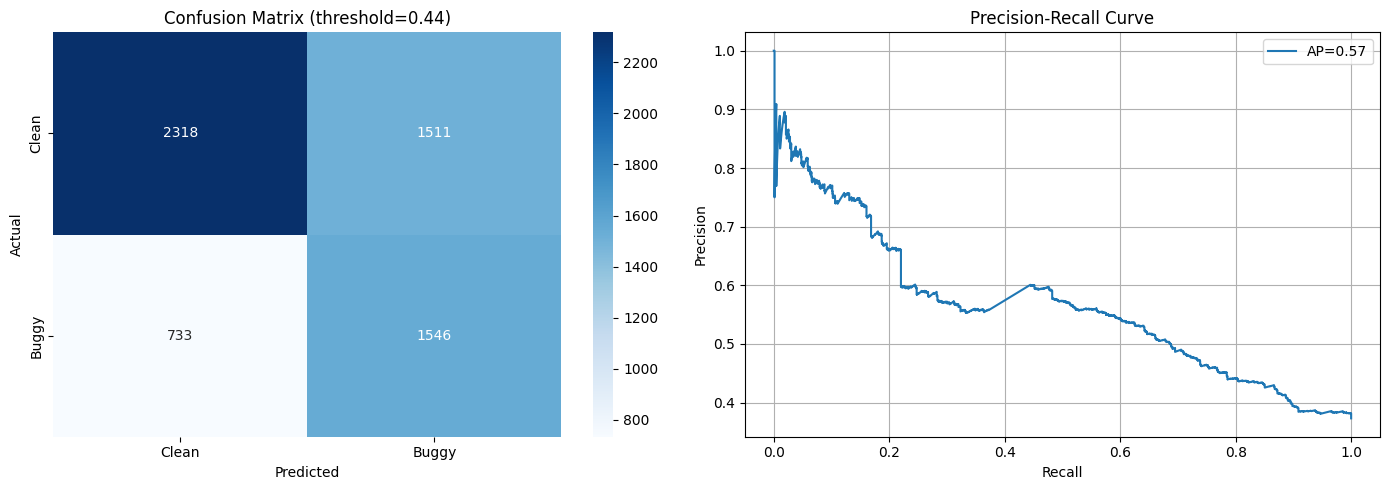

/tmp/ipykernel_779/2036042269.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val_scaled, feature_names=FEATURE_NAMES, plot_type='bar', show=False)


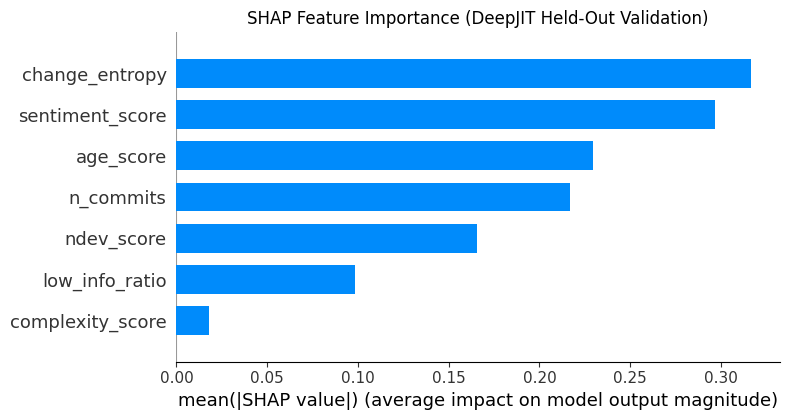

In [ ]:
# ── 16. Visualizations ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score

# Confusion matrix
cm = confusion_matrix(y_val_dj, y_pred_opt)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Clean', 'Buggy'], yticklabels=['Clean', 'Buggy'])
axes[0].set_title(f'Confusion Matrix (threshold={best_thresh:.2f})')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_val_dj, y_scores)
ap = average_precision_score(y_val_dj, y_scores)
axes[1].plot(recall, precision, label=f'AP={ap:.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

# SHAP feature importance
masker = shap.maskers.Independent(X_train_scaled, max_samples=100)
explainer = shap.LinearExplainer(risk_model, masker)
shap_values = explainer.shap_values(X_val_scaled)
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_val_scaled, feature_names=FEATURE_NAMES, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (DeepJIT Held-Out Validation)')
plt.tight_layout(); plt.show()